In [2]:
import os
import time
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

from model import UNetSODModel

In [7]:
MODEL_PATH = "saved_models/unet_model.pth"
IMAGE_SIZE = 224

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = UNetSODModel().to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

print("Final U-Net model loaded successfully.")

Using device: cpu
Final U-Net model loaded successfully.


In [8]:
image_path = "data/images/0195.jpg"

In [9]:

original = cv2.imread(image_path)

if original is None:
    raise FileNotFoundError(f"Image not found: {image_path}")

original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

resized = cv2.resize(original_rgb, (IMAGE_SIZE, IMAGE_SIZE))
normalized = resized.astype(np.float32) / 255.0

input_tensor = torch.from_numpy(normalized).permute(2, 0, 1).unsqueeze(0)
input_tensor = input_tensor.to(device)

start_time = time.time()

with torch.no_grad():
    prediction = model(input_tensor)

end_time = time.time()

inference_time = end_time - start_time

pred_mask = prediction.squeeze().cpu().numpy()
pred_binary = (pred_mask > 0.5).astype(np.float32)

print(f"Inference time per image: {inference_time:.4f} seconds")

Inference time per image: 0.1057 seconds


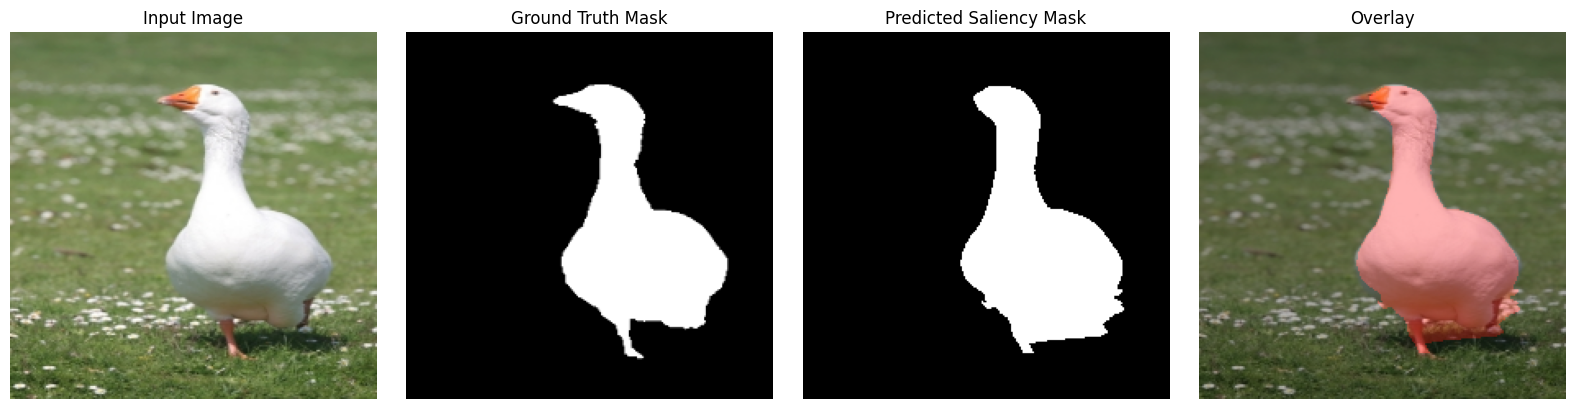

In [11]:
mask_path = "data/masks/0195.png"

ground_truth = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

ground_truth = cv2.resize(
    ground_truth,
    (IMAGE_SIZE, IMAGE_SIZE)
)

ground_truth = ground_truth.astype(np.float32) / 255.0


overlay = resized.copy().astype(np.float32) / 255.0

red_mask = np.zeros_like(overlay)
red_mask[:, :, 0] = pred_binary

overlay = overlay * 0.7 + red_mask * 0.3
overlay = np.clip(overlay, 0, 1)


plt.figure(figsize=(16, 4))

plt.subplot(1, 4, 1)
plt.title("Input Image")
plt.imshow(resized)
plt.axis("off")

plt.subplot(1, 4, 2)
plt.title("Ground Truth Mask")
plt.imshow(ground_truth, cmap="gray")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.title("Predicted Saliency Mask")
plt.imshow(pred_binary, cmap="gray")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.title("Overlay")
plt.imshow(overlay)
plt.axis("off")

plt.tight_layout()
plt.show()